<div style="display: flex; align-items: center; justify-content: flex-start; text-align: left;">
    <img src="https://upload.wikimedia.org/wikipedia/commons/thumb/6/68/Logo_universidad_icesi.svg/960px-Logo_universidad_icesi.svg.png" width="300" style="margin-right: 20px;">
    <div>
        <h3 style="margin: 0;">FACULTAD BARBERI DE INGENIERÍA, DISEÑO Y CIENCIAS APLICADAS</h3>
        <h3 style="margin: 0;">ALGORITMOS Y PROGRAMACIÓN III</h3>
    </div>
</div>

# Laboratorio 1: Predicción y Clasificación en la Industria Azucarera

Integrantes:
- ANGY MARIA HURTADO OSORIO A00401755
- HIDEKI TAMURA HERNANDEZ A00348618
- DAVID VERGARA LAVERDE A00XXXXXX


# 1. Carga de datos

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Cargar datasets
df_reg = pd.read_excel("datos/HISTORICO_SUERTES.xlsx")
df_clf = pd.read_excel("datos/BD_IPSA_1940.xlsx")

print("Regresión:", df_reg.shape)
print("Clasificación:", df_clf.shape)

Regresión: (21027, 85)
Clasificación: (2187, 21)


# 2. Exploración inicial

## 2.1 Vista general de los datos

### Regresión:

In [2]:
df_reg.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21027 entries, 0 to 21026
Data columns (total 85 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   Período                    21027 non-null  int64         
 1   Hacienda                   21027 non-null  int64         
 2   Nombre                     21027 non-null  object        
 3   Zona                       21027 non-null  object        
 4   Tenencia                   21026 non-null  float64       
 5   Suerte                     21027 non-null  object        
 6   Suelo                      17269 non-null  object        
 7   Area Neta                  21027 non-null  float64       
 8   Dist Km                    21022 non-null  float64       
 9   Variedad                   21027 non-null  object        
 10  Cod.Estado #               21027 non-null  int64         
 11  Cod.Estado                 21027 non-null  object        
 12  F.Si

### Clasificación:

In [3]:
df_clf.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2187 entries, 0 to 2186
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Unnamed: 0      2187 non-null   int64  
 1   NOME            2187 non-null   object 
 2   FAZ             2187 non-null   int64  
 3   TAL             2187 non-null   object 
 4   tipocorte       2187 non-null   object 
 5   variedad        2187 non-null   object 
 6   madurada        2187 non-null   object 
 7   producto        2187 non-null   object 
 8   dosismad        2187 non-null   float64
 9   semsmad         2187 non-null   float64
 10  edad            2187 non-null   float64
 11  cortes          2187 non-null   int64  
 12  me              2187 non-null   float64
 13  vejez           2187 non-null   float64
 14  sacarosa        2187 non-null   float64
 15  mes             2187 non-null   int64  
 16  periodo         2187 non-null   int64  
 17  TCH             2187 non-null   i

## 2.2 Tipos de datos y descripción

### Regresión:

In [4]:
df_reg.head()

,Período,Hacienda,Nombre,Zona,Tenencia,Suerte,Suelo,Area Neta,Dist Km,Variedad,...,Humedad Rel Media Ciclo,Oscilacion Temp Med 0-3,Oscilacion Temp Ciclo,Sum Oscilacion Temp Ciclo,Radicion Solar 0-3,Radiacion Solar Ciclo,Precipitacion 0_3,Precipitacion Ciclo,Evaporacion 0-3,Evaporacion Ciclo
0,201701,80493,LA CONCHA,IP02,51.0,002A,CANTARINA,6.00,4.3,CC85-92,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,201701,81284,UKRANIA INCAUCA,IP05,81.0,039B,NaN,1.45,NaN,CC85-92,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,201701,80203,EL AMPARO SAA,IP05,31.0,007,CORINTIAS,8.24,23.0,CC01-1228,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,201701,81380,SAN JUDAS INCAUCA,IP05,82.0,013A,NaN,1.05,66.5,CC01-1940,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,201701,80298,JAVA,IP06,31.0,025A,GALPON,4.53,17.0,RB73-2223,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Clasificación:

In [5]:
df_clf.head()

,Unnamed: 0,NOME,FAZ,TAL,tipocorte,variedad,madurada,producto,dosismad,semsmad,...,cortes,me,vejez,sacarosa,mes,periodo,TCH,lluvias,grupo_tenencia,pct_diatrea
0,11,AMAIME SILCA,81291,40,Mecanizado Verde,CC01-1940,SI,BONUS 250 EC REGULADOR FISIOLÓGICO,0.8,8.3,...,4,12.7,2.4,14.0,12,202012,112,137,3,6.2
1,12,AMAIME SILCA,81291,41,Mecanizado Verde,CC01-1940,SI,BONUS 250 EC REGULADOR FISIOLÓGICO,0.8,6.3,...,2,7.8,2.3,13.0,3,201903,157,0,3,3.5
2,13,AMAIME SILCA,81291,41,Mecanizado Verde,CC01-1940,SI,BONUS 250 EC REGULADOR FISIOLÓGICO,0.6,7.9,...,3,8.8,1.8,13.3,3,202003,167,68,3,4.3
3,15,AMAIME SILCA,81291,43,Mecanizado Verde,CC01-1940,SI,BONUS 250 EC REGULADOR FISIOLÓGICO,0.8,6.6,...,1,6.1,2.5,13.4,3,201903,156,0,3,3.5
4,16,AMAIME SILCA,81291,43,Mecanizado Verde,CC01-1940,SI,BONUS 250 EC REGULADOR FISIOLÓGICO,0.6,8.1,...,2,7.9,2.1,14.0,3,202003,151,68,3,4.3


# 3. Análisis de datos faltantes

## 3.0 Exclusión de variables con data leakage

Antes de analizar nulos, se excluyen las variables que son métricas derivadas de las variables objetivo o que se conocen únicamente después de la cosecha. Incluirlas como predictores genera fuga de información (*data leakage*) y produce modelos con rendimiento artificialmente inflado que no funcionarían en producción.

In [6]:
# Variables que NO pueden usarse como predictores — data leakage
# HISTORICO_SUERTES: derivadas de TCH o %Sac.Caña, o calculadas post-cosecha
LEAKAGE_REG = ['TonUltCorte', 'TCHM', 'Ton.Azucar', 'Rdto',
               'TAH', 'TAHM', '%ATR', 'KATRHM', '%Sac.Muestreadora']

# BD_IPSA_1940: derivadas de TCH o sacarosa
LEAKAGE_CLF = ['TAH', 'TAHM', 'TCHM', 'KATRHM', 'Rdto', '%Sac.Muestreadora']

# Nota: TCH, %Sac.Caña y sacarosa son los targets — se tratan por separado

print("Leakage a excluir en HISTORICO_SUERTES:")
print(" ", [c for c in LEAKAGE_REG if c in df_reg.columns])
print("\nLeakage a excluir en BD_IPSA_1940:")
print(" ", [c for c in LEAKAGE_CLF if c in df_clf.columns])

Leakage a excluir en HISTORICO_SUERTES:
  ['TonUltCorte', 'TCHM', 'Ton.Azucar', 'Rdto', 'TAH', 'TAHM', '%ATR', 'KATRHM', '%Sac.Muestreadora']

Leakage a excluir en BD_IPSA_1940:
  []


## 3.1 Porcentaje de valores nulos

Se calcula el porcentaje de valores faltantes por columna en ambos datasets para decidir entre imputar o descartar cada variable.

In [7]:
def reporte_nulos(df, nombre):
    """Tabla de nulos ordenada de mayor a menor porcentaje."""
    nulos  = df.isnull().sum()
    pct    = (nulos / len(df) * 100).round(2)
    reporte = pd.DataFrame({
        'Nulos'      : nulos,
        '% Faltante' : pct,
        'Dtype'      : df.dtypes
    }).query('Nulos > 0').sort_values('% Faltante', ascending=False)
    print(f"\n{'='*55}")
    print(f"Dataset: {nombre}  |  Filas: {len(df)}  |  Cols: {df.shape[1]}")
    print(f"{'='*55}")
    if reporte.empty:
        print("  → Sin valores nulos detectados.")
    else:
        print(reporte.to_string())
    return reporte

nulos_reg = reporte_nulos(df_reg, "HISTORICO_SUERTES")
nulos_clf = reporte_nulos(df_clf, "BD_IPSA_1940")


Dataset: HISTORICO_SUERTES  |  Filas: 21027  |  Cols: 85
                           Nulos  % Faltante           Dtype
Sum Oscilacion Temp Ciclo  21027      100.00         float64
Fert.Nitrogen.             21027      100.00         float64
Urea 46%                   20304       96.56         float64
NITRAX-S                   20279       96.44         float64
MEZ                        20056       95.38         float64
MicroZinc                  19878       94.54         float64
Boro Granul.               19742       93.89         float64
Sul.Amonio                 19670       93.55         float64
NITO_XTEND                 17348       82.50         float64
Vinaza                     16929       80.51         float64
Oscilacion Temp Ciclo      16497       78.46         float64
Oscilacion Temp Med 0-3    16497       78.46         float64
Radicion Solar 0-3         16497       78.46         float64
Temp. Media Ciclo          16497       78.46         float64
Temp Max Ciclo             

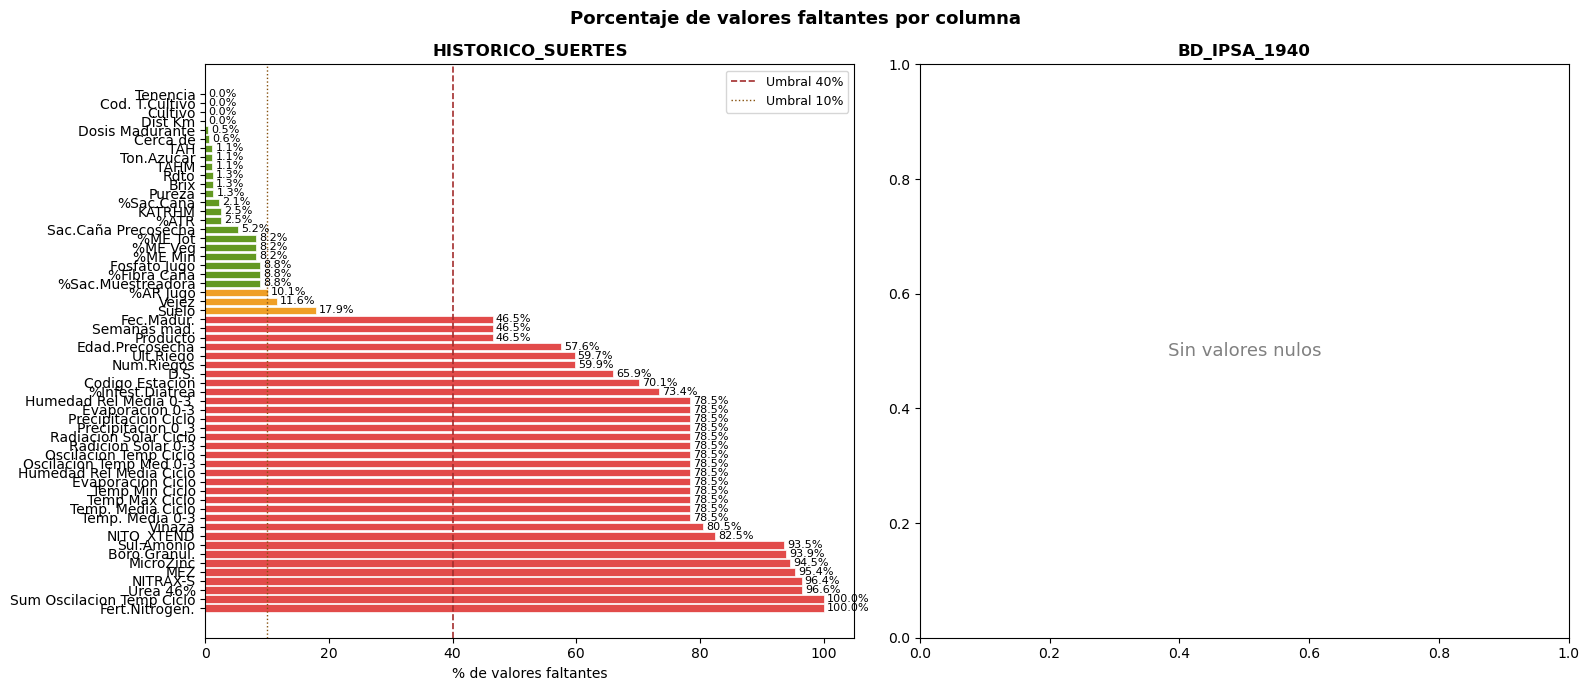

Verde: < 10% | Naranja: 10-40% | Rojo: > 40% (candidato a descartar)


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for ax, (df, nombre) in zip(axes, [(df_reg, "HISTORICO_SUERTES"),
                                    (df_clf, "BD_IPSA_1940")]):
    pct_nulos = (df.isnull().mean() * 100).sort_values(ascending=False)
    pct_nulos = pct_nulos[pct_nulos > 0]

    if pct_nulos.empty:
        ax.text(0.5, 0.5, "Sin valores nulos", ha="center", va="center",
                transform=ax.transAxes, fontsize=13, color="gray")
        ax.set_title(nombre, fontweight='bold')
        continue

    colores = ['#E24B4A' if p > 40 else '#EF9F27' if p > 10 else '#639922'
               for p in pct_nulos]
    bars = ax.barh(pct_nulos.index, pct_nulos.values,
                   color=colores, edgecolor='white', linewidth=0.5)
    ax.axvline(x=40, color='#A32D2D', linestyle='--', linewidth=1.2, label='Umbral 40%')
    ax.axvline(x=10, color='#854F0B', linestyle=':',  linewidth=1.0, label='Umbral 10%')
    ax.set_xlabel('% de valores faltantes')
    ax.set_title(nombre, fontweight='bold')
    ax.legend(fontsize=9)
    for bar, val in zip(bars, pct_nulos.values):
        ax.text(val + 0.5, bar.get_y() + bar.get_height() / 2,
                f'{val:.1f}%', va='center', fontsize=8)

plt.suptitle("Porcentaje de valores faltantes por columna", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('nulos_por_columna.png', dpi=150, bbox_inches='tight')
plt.show()
print("Verde: < 10% | Naranja: 10-40% | Rojo: > 40% (candidato a descartar)")

## 3.2 BD_IPSA_1940 — Sin valores nulos

El dataset BD_IPSA_1940 **no presenta valores nulos** en ninguna de sus columnas. Sin embargo, durante el diagnóstico se detectaron **2 valores negativos en `semsmad`** (semanas de maduración), lo cual no tiene sentido agronómico. Se corrigen con `clip(lower=0)`. El resto del preprocesamiento de este dataset (exclusión de leakage, codificación de categóricas y división train/test) se realiza en la Sección 5.

In [9]:
df_clf_clean = df_clf.copy()

# Excluir leakage
cols_drop_clf = [c for c in LEAKAGE_CLF if c in df_clf_clean.columns]
df_clf_clean.drop(columns=cols_drop_clf, inplace=True)
print(f"Leakage eliminado: {cols_drop_clf}")

# Corregir negativos en semsmad
if 'semsmad' in df_clf_clean.columns:
    neg = (df_clf_clean['semsmad'] < 0).sum()
    df_clf_clean['semsmad'] = df_clf_clean['semsmad'].clip(lower=0)
    print(f"'semsmad': {neg} valores negativos → corregidos a 0")

print(f"\nNulos en BD_IPSA_1940: {df_clf_clean.isnull().sum().sum()}")
print(f"Shape: {df_clf_clean.shape}")

Leakage eliminado: []
'semsmad': 2 valores negativos → corregidos a 0

Nulos en BD_IPSA_1940: 0
Shape: (2187, 21)


## 3.3 HISTORICO_SUERTES — Estrategia de imputación

Este dataset sí presenta valores faltantes. La estrategia se define según el contexto agronómico, no solo por criterio estadístico:

| Criterio | Decisión | Justificación |
|---|---|---|
| **% nulos > 40 %** | Descartar columna | Imputar con alta incertidumbre introduce más ruido que información |
| **Variable objetivo sin valor** | Eliminar fila | No se puede entrenar ni evaluar un modelo sin el target |
| **`Dosis Madurante` / `Semanas mad.` = NaN** | Imputar con **0** | Ausencia de registro indica que no se aplicó madurante |
| **Numéricas restantes** | Mediana por **Zona** + global como fallback | Controla la variabilidad espacial del valle del río Cauca |
| **Categóricas** | Categoría `'Desconocido'` | Preserva la fila y señaliza la ausencia explícitamente |

In [10]:
df_reg_clean = df_reg.copy()
UMBRAL = 40

# 1. Excluir leakage 
cols_drop_leakage = [c for c in LEAKAGE_REG if c in df_reg_clean.columns]
df_reg_clean.drop(columns=cols_drop_leakage, inplace=True)
print(f"[1] Leakage eliminado ({len(cols_drop_leakage)} cols): {cols_drop_leakage}")

# 2. Descartar columnas con > 40 % nulos
pct_cols = (df_reg_clean.isnull().mean() * 100)
cols_drop_umbral = pct_cols[pct_cols > UMBRAL].index.tolist()
df_reg_clean.drop(columns=cols_drop_umbral, inplace=True)
print(f"[2] Descartadas por >{UMBRAL}% nulos ({len(cols_drop_umbral)} cols): {cols_drop_umbral}")

# 3. Eliminar filas sin target
# %Sac.Caña tenía 449 nulos — no se imputa, se eliminan las filas
targets_reg = ['TCH', '%Sac.Caña']
filas_antes = len(df_reg_clean)
df_reg_clean.dropna(subset=[t for t in targets_reg if t in df_reg_clean.columns], inplace=True)
eliminadas  = filas_antes - len(df_reg_clean)
print(f"[3] Filas eliminadas por target nulo: {eliminadas} "
      f"({filas_antes} → {len(df_reg_clean)}, {eliminadas/filas_antes*100:.1f}% del total)")

# 4. Dosis Madurante y Semanas mad → 0
for col in ['Dosis Madurante', 'Semanas mad.']:
    if col in df_reg_clean.columns and df_reg_clean[col].isnull().sum() > 0:
        n = df_reg_clean[col].isnull().sum()
        df_reg_clean[col] = df_reg_clean[col].fillna(0)
        print(f"[4] '{col}': {n} nulos → 0 (no se aplicó madurante)")

# 5. Numéricas restantes → mediana por Zona + global fallback
cols_num = [c for c in df_reg_clean.select_dtypes(include='number').columns
            if c not in targets_reg]
for col in cols_num:
    if df_reg_clean[col].isnull().sum() > 0:
        n = df_reg_clean[col].isnull().sum()
        if 'Zona' in df_reg_clean.columns:
            df_reg_clean[col] = df_reg_clean.groupby('Zona')[col].transform(
                lambda x: x.fillna(x.median()))
        df_reg_clean[col] = df_reg_clean[col].fillna(df_reg_clean[col].median())
        print(f"[5] '{col}': {n} nulos → mediana por Zona")

# 6. Categóricas → 'Desconocido'
for col in df_reg_clean.select_dtypes(include='object').columns:
    if df_reg_clean[col].isnull().sum() > 0:
        n = df_reg_clean[col].isnull().sum()
        df_reg_clean[col] = df_reg_clean[col].fillna('Desconocido')
        print(f"[6] '{col}': {n} nulos → 'Desconocido'")

print(f"\n→ Nulos restantes: {df_reg_clean.isnull().sum().sum()}")
print(f"→ Shape final: {df_reg_clean.shape}")

[1] Leakage eliminado (9 cols): ['TonUltCorte', 'TCHM', 'Ton.Azucar', 'Rdto', 'TAH', 'TAHM', '%ATR', 'KATRHM', '%Sac.Muestreadora']
[2] Descartadas por >40% nulos (33 cols): ['D.S.', 'Ult.Riego', 'Fec.Madur.', 'Producto', 'Semanas mad.', 'Edad.Precosecha', 'Num.Riegos', '%Infest.Diatrea', 'Fert.Nitrogen.', 'Urea 46%', 'MEZ', 'Boro Granul.', 'MicroZinc', 'NITO_XTEND', 'Sul.Amonio', 'NITRAX-S', 'Vinaza', 'Codigo Estacion', 'Temp. Media 0-3', 'Temp. Media Ciclo', 'Temp Max Ciclo', 'Temp Min Ciclo', 'Humedad Rel Media 0-3 ', 'Humedad Rel Media Ciclo', 'Oscilacion Temp Med 0-3', 'Oscilacion Temp Ciclo', 'Sum Oscilacion Temp Ciclo', 'Radicion Solar 0-3', 'Radiacion Solar Ciclo', 'Precipitacion 0_3', 'Precipitacion Ciclo', 'Evaporacion 0-3', 'Evaporacion Ciclo']
[3] Filas eliminadas por target nulo: 449 (21027 → 20578, 2.1% del total)
[4] 'Dosis Madurante': 96 nulos → 0 (no se aplicó madurante)
[5] 'Tenencia': 1 nulos → mediana por Zona
[5] 'Dist Km': 5 nulos → mediana por Zona
[5] 'Cod. T.Cu

## 3.4 Verificación final

  VERIFICACIÓN FINAL — POST IMPUTACIÓN
  HISTORICO_SUERTES : (20578, 43)  | Nulos: 0
  BD_IPSA_1940      : (2187, 21)   | Nulos: 0


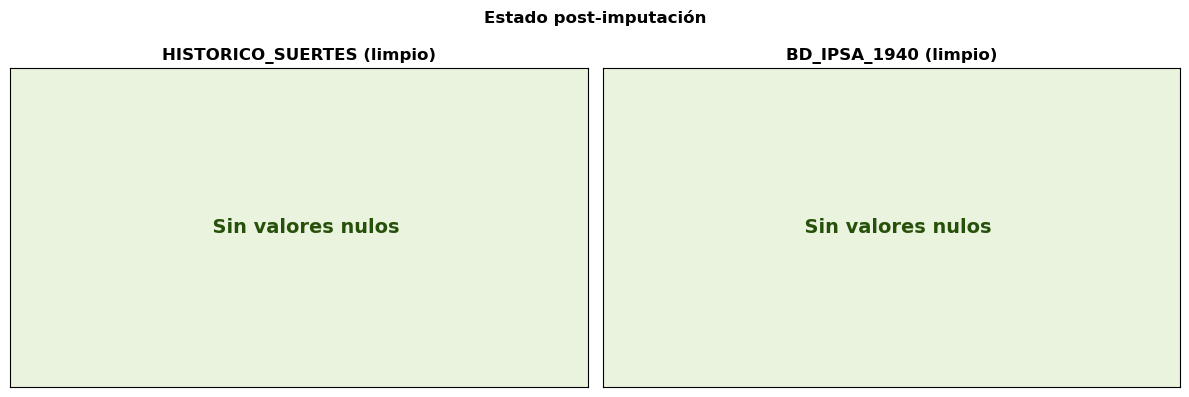

In [11]:
print("=" * 55)
print("  VERIFICACIÓN FINAL — POST IMPUTACIÓN")
print("=" * 55)
print(f"  HISTORICO_SUERTES : {df_reg_clean.shape}  | Nulos: {df_reg_clean.isnull().sum().sum()}")
print(f"  BD_IPSA_1940      : {df_clf_clean.shape}   | Nulos: {df_clf_clean.isnull().sum().sum()}")
print("=" * 55)

# Confirmación visual
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, (df, nombre) in zip(axes, [(df_reg_clean, "HISTORICO_SUERTES (limpio)"),
                                    (df_clf_clean,  "BD_IPSA_1940 (limpio)")]):
    pct = (df.isnull().mean() * 100).sort_values(ascending=False)
    pct = pct[pct > 0]
    if pct.empty:
        ax.text(0.5, 0.5, "  Sin valores nulos", ha="center", va="center",
                transform=ax.transAxes, fontsize=14,
                color="#27500A", fontweight="bold")
        ax.set_facecolor("#EAF3DE")
        ax.set_xticks([])
        ax.set_yticks([])
    else:
        ax.barh(pct.index, pct.values, color="#E24B4A")
        ax.set_xlabel("% nulos restantes")
    ax.set_title(nombre, fontweight="bold")

plt.suptitle("Estado post-imputación", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

# 4. Análisis Exploratorio de Datos (EDA)

## 4.1 Distribución de las variables objetivo

Se analizan la distribución de TCH y %Sac.Caña usando histogramas con KDE para evaluar normalidad.

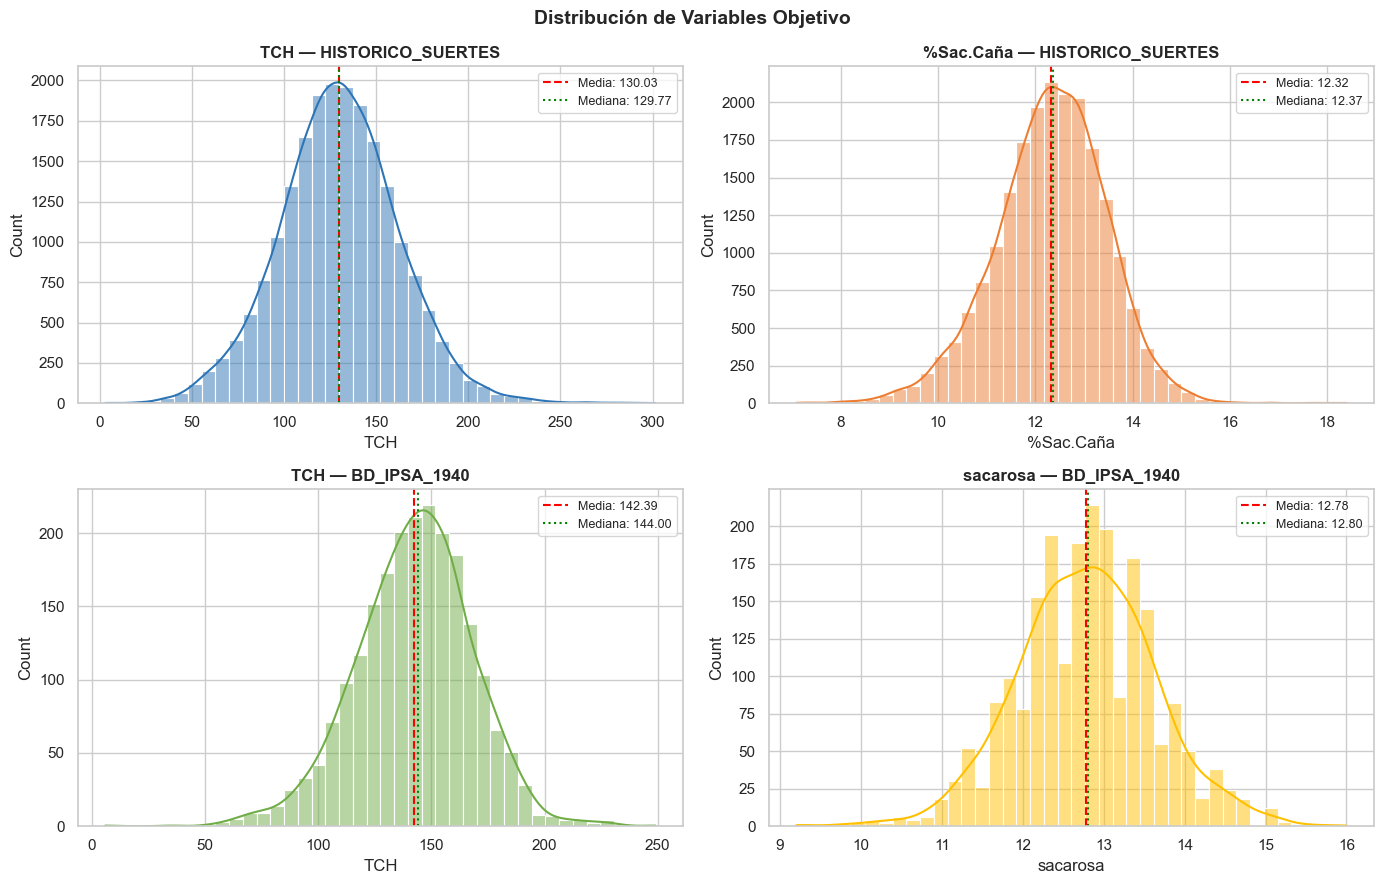

Figura guardada: outputs/figures/fig1_distribuciones_targets.png
Columnas usadas: TCH, %Sac.Caña (HIST), TCH, sacarosa (IPSA)


In [12]:
import os
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

os.makedirs("outputs/figures", exist_ok=True)
os.makedirs("outputs/metrics", exist_ok=True)
os.makedirs("outputs/datos_limpios", exist_ok=True)

sns.set_theme(style="whitegrid", palette="muted")

# Nombre de sacarosa en df_clf_clean puede ser "sacarosa" o "%Sac.Cana"
sac_clf_col = next((c for c in df_clf_clean.columns if "sac" in c.lower() or "sacarosa" in c.lower()), None)
tch_clf_col = "TCH" if "TCH" in df_clf_clean.columns else None

pairs = [
    ("TCH",      df_reg_clean, "HISTORICO_SUERTES"),
    ("%Sac.Caña", df_reg_clean, "HISTORICO_SUERTES"),
    (tch_clf_col, df_clf_clean, "BD_IPSA_1940"),
    (sac_clf_col, df_clf_clean, "BD_IPSA_1940"),
]

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
colors = ["#2E75B6", "#ED7D31", "#70AD47", "#FFC000"]

for i, (col, df, label) in enumerate(pairs):
    ax = axes[i//2][i%2]
    if col and col in df.columns:
        sns.histplot(df[col].dropna(), kde=True, ax=ax, color=colors[i], bins=40)
        ax.axvline(df[col].mean(), color="red", linestyle="--", linewidth=1.5,
                   label=f"Media: {df[col].mean():.2f}")
        ax.axvline(df[col].median(), color="green", linestyle=":", linewidth=1.5,
                   label=f"Mediana: {df[col].median():.2f}")
        ax.set_title(f"{col} — {label}", fontweight="bold")
        ax.set_xlabel(col)
        ax.legend(fontsize=9)
    else:
        ax.text(0.5, 0.5, f"Columna no encontrada", ha="center", va="center",
                transform=ax.transAxes, fontsize=11, color="gray")
        ax.set_title(f"Subplot {i+1}", fontweight="bold")

plt.suptitle("Distribución de Variables Objetivo", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("outputs/figures/fig1_distribuciones_targets.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figura guardada: outputs/figures/fig1_distribuciones_targets.png")
print(f"Columnas usadas: TCH, %Sac.Caña (HIST), {tch_clf_col}, {sac_clf_col} (IPSA)")


## 4.2 Detección de Outliers

Se usan boxplots para identificar valores atípicos en las variables objetivo. Los outliers se calculan mediante el rango intercuartílico (IQR).

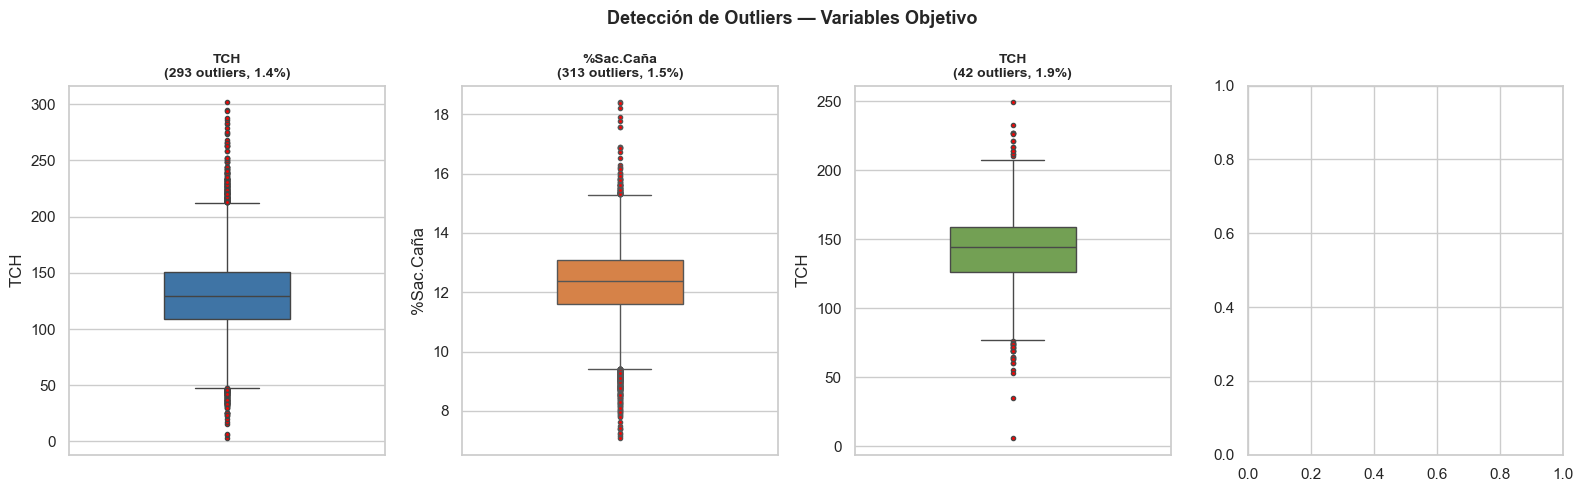

Figura guardada: outputs/figures/fig2_outliers.png

=== Reporte de Outliers ===

HISTORICO_SUERTES:
  TCH: Q1=109.22, Q3=150.56, IQR=41.34 → 293 outliers (1.4%)
  %Sac.Caña: Q1=11.62, Q3=13.09, IQR=1.47 → 313 outliers (1.5%)

BD_IPSA_1940:
  TCH: Q1=126.00, Q3=159.00, IQR=33.00 → 42 outliers (1.9%)


In [13]:
fig, axes = plt.subplots(1, 4, figsize=(16, 5))

pairs = [
    (df_reg_clean, "TCH", "#2E75B6"),
    (df_reg_clean, "%Sac.Caña", "#ED7D31"),
]
if "TCH" in df_clf_clean.columns:
    pairs.append((df_clf_clean, "TCH", "#70AD47"))
if "%Sac.Caña" in df_clf_clean.columns:
    pairs.append((df_clf_clean, "%Sac.Caña", "#FFC000"))

for ax, (df, col, color) in zip(axes, pairs):
    if col in df.columns:
        sns.boxplot(y=df[col].dropna(), ax=ax, color=color, width=0.4,
                    flierprops={"marker": "o", "markerfacecolor": "red", "markersize": 3})
        q1, q3 = df[col].quantile([0.25, 0.75])
        iqr = q3 - q1
        outliers = ((df[col] < (q1 - 1.5*iqr)) | (df[col] > (q3 + 1.5*iqr))).sum()
        ax.set_title(f'{col}\n({outliers} outliers, {outliers/len(df)*100:.1f}%)', fontweight='bold', fontsize=10)
        ax.set_xlabel("")

plt.suptitle("Detección de Outliers — Variables Objetivo", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("outputs/figures/fig2_outliers.png", dpi=150, bbox_inches='tight')
plt.show()
print("Figura guardada: outputs/figures/fig2_outliers.png")

# Reporte cuantitativo
print("\n=== Reporte de Outliers ===")
for df, nombre in [(df_reg_clean, "HISTORICO_SUERTES"), (df_clf_clean, "BD_IPSA_1940")]:
    print(f"\n{nombre}:")
    for col in ["TCH", "%Sac.Caña"]:
        if col in df.columns:
            q1, q3 = df[col].quantile([0.25, 0.75])
            iqr = q3 - q1
            n_out = ((df[col] < (q1 - 1.5*iqr)) | (df[col] > (q3 + 1.5*iqr))).sum()
            print(f"  {col}: Q1={q1:.2f}, Q3={q3:.2f}, IQR={iqr:.2f} → {n_out} outliers ({n_out/len(df)*100:.1f}%)")


## 4.3 Matriz de Correlación

Se analiza la correlación entre variables numéricas para identificar los mejores predictores de TCH y %Sac.Caña, y detectar multicolinealidad.

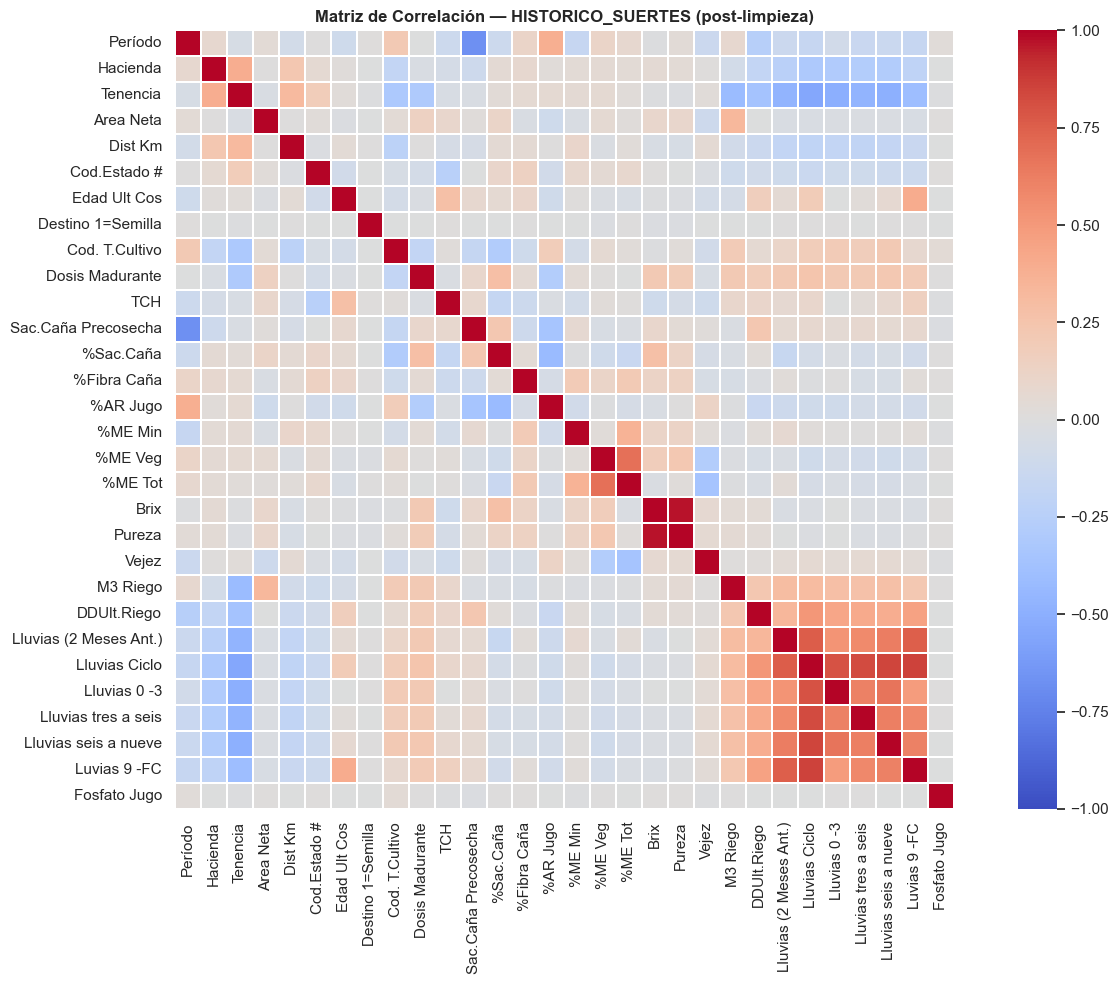

Figura guardada: outputs/figures/fig3_correlacion_completa.png


In [14]:
# Seleccionar columnas numéricas relevantes (sin leakage, sin alta nulidad)
cols_num_reg = df_reg_clean.select_dtypes(include='number').columns.tolist()

corr_matrix = df_reg_clean[cols_num_reg].corr()

# Figura: mapa de calor completo
fig, ax = plt.subplots(figsize=(14, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(corr_matrix, ax=ax, cmap="coolwarm", center=0,
            annot=False, linewidths=0.3, mask=False,
            vmin=-1, vmax=1, square=True)
ax.set_title("Matriz de Correlación — HISTORICO_SUERTES (post-limpieza)", fontweight='bold', fontsize=12)
plt.tight_layout()
plt.savefig("outputs/figures/fig3_correlacion_completa.png", dpi=150, bbox_inches='tight')
plt.show()
print("Figura guardada: outputs/figures/fig3_correlacion_completa.png")



Top correlaciones con TCH:
Edad Ult Cos     0.280524
Cod.Estado #    -0.242832
%Sac.Caña       -0.168060
Luvias 9 -FC     0.153096
%Fibra Caña     -0.124765
Período         -0.122921
Brix            -0.104216
Vejez           -0.104121
DDUlt.Riego      0.096214
Lluvias Ciclo    0.090787
M3 Riego         0.088029
Area Neta        0.086959

Top correlaciones con %Sac.Caña:
%AR Jugo                 -0.426237
Dosis Madurante           0.288457
Cod. T.Cultivo           -0.282659
Brix                      0.278750
Sac.Caña Precosecha       0.229455
TCH                      -0.168060
Lluvias (2 Meses Ant.)   -0.156232
%ME Tot                  -0.143012
Pureza                    0.121478
Período                  -0.120753
Area Neta                 0.113064
Cod.Estado #              0.098363


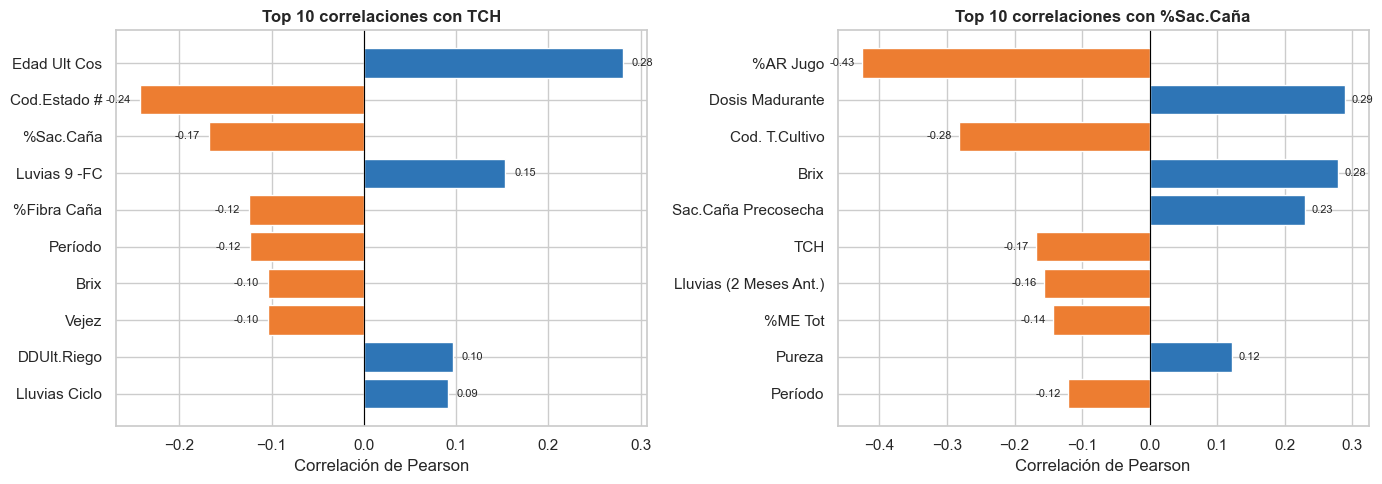

Figura guardada: outputs/figures/fig4_top_correlaciones.png


In [15]:
# Top correlaciones con los targets
for target in ["TCH", "%Sac.Caña"]:
    if target in corr_matrix.columns:
        top = corr_matrix[target].drop(index=[target]).abs().sort_values(ascending=False).head(12)
        print(f"\nTop correlaciones con {target}:")
        print(corr_matrix[target].drop(index=[target]).loc[top.index].to_string())

# Figura: Top correlaciones con TCH y Sac
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, target in zip(axes, ["TCH", "%Sac.Caña"]):
    if target in corr_matrix.columns:
        top_corr = corr_matrix[target].drop(index=[target]).abs().sort_values(ascending=False).head(10)
        vals = corr_matrix[target].loc[top_corr.index]
        colors_bar = ["#2E75B6" if v > 0 else "#ED7D31" for v in vals]
        ax.barh(top_corr.index[::-1], vals[::-1], color=colors_bar[::-1])
        ax.axvline(0, color='black', linewidth=0.8)
        ax.set_title(f"Top 10 correlaciones con {target}", fontweight='bold')
        ax.set_xlabel("Correlación de Pearson")
        for j, (idx, v) in enumerate(zip(top_corr.index[::-1], vals[::-1])):
            ax.text(v + (0.01 if v >= 0 else -0.01), j, f"{v:.2f}",
                    va='center', ha='left' if v >= 0 else 'right', fontsize=8)

plt.tight_layout()
plt.savefig("outputs/figures/fig4_top_correlaciones.png", dpi=150, bbox_inches='tight')
plt.show()
print("Figura guardada: outputs/figures/fig4_top_correlaciones.png")


## 4.4 Relaciones clave entre predictores y variables objetivo

Se exploran visualmente las relaciones más relevantes identificadas en la matriz de correlación y justificadas por el contexto agronómico.

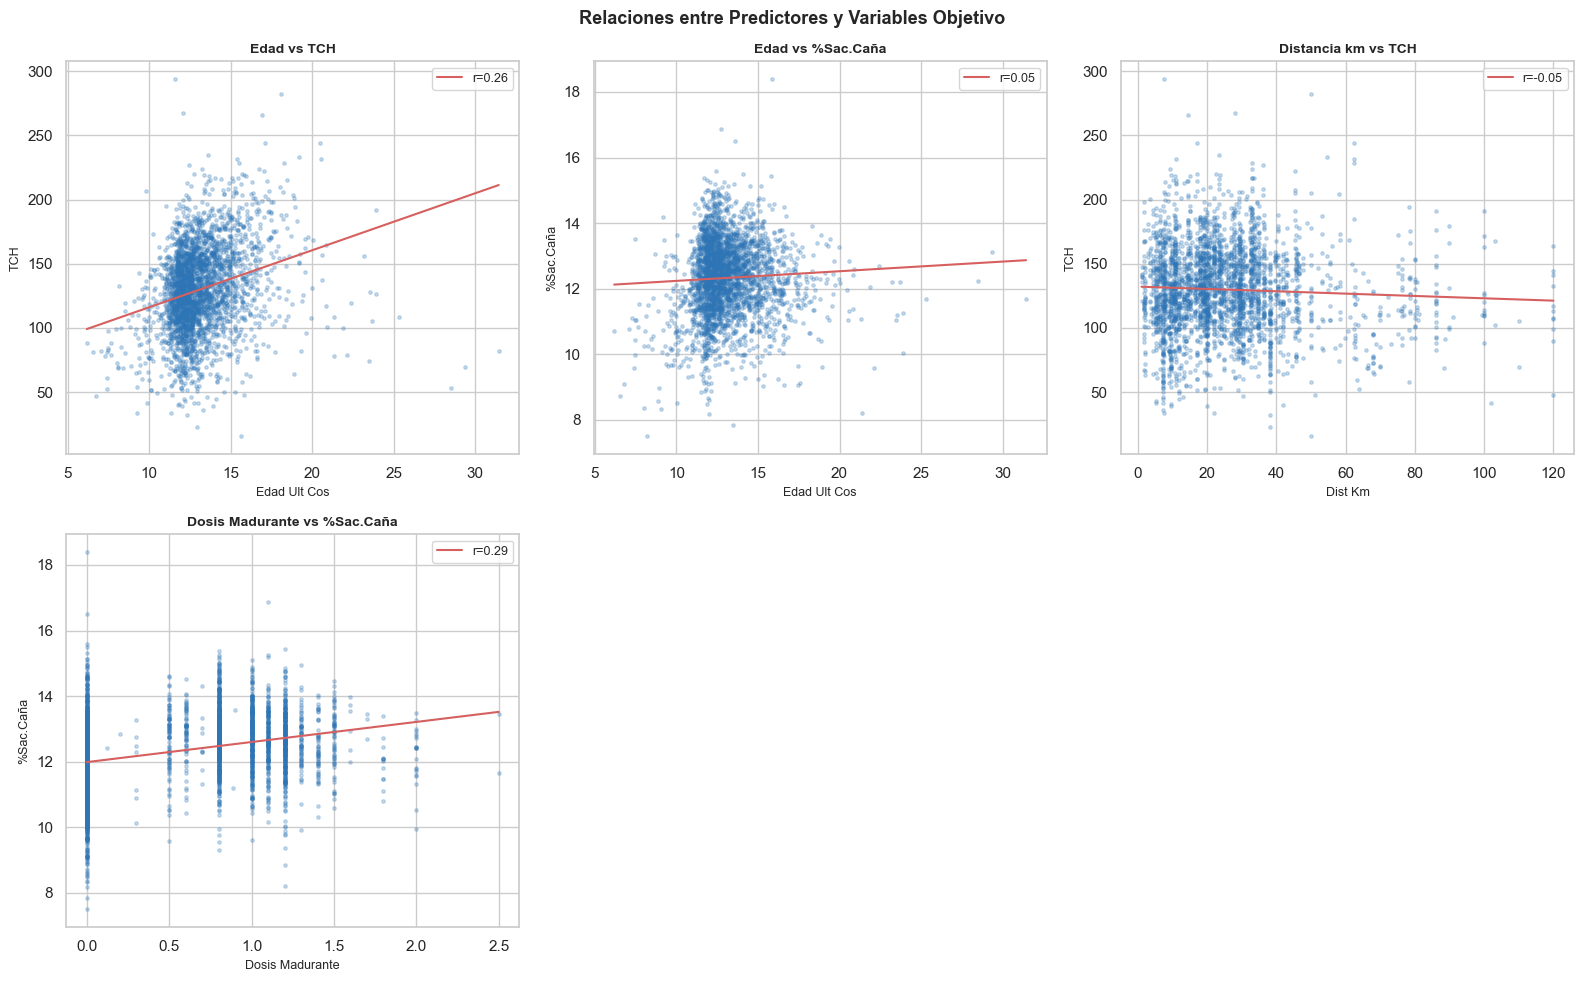

Figura guardada: outputs/figures/fig5_relaciones_predictores.png


In [16]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

scatter_pairs = [
    ("Edad Ult Cos", "TCH",       df_reg_clean, "Edad vs TCH"),
    ("Edad Ult Cos", "%Sac.Caña", df_reg_clean, "Edad vs %Sac.Caña"),
    ("Dist Km",      "TCH",       df_reg_clean, "Distancia km vs TCH"),
    ("Dosis Madurante", "%Sac.Caña", df_reg_clean, "Dosis Madurante vs %Sac.Caña"),
    ("Semanas mad.", "%Sac.Caña", df_reg_clean, "Semanas Maduración vs %Sac.Caña"),
    ("Semanas mad.", "TCH",       df_reg_clean, "Semanas Maduración vs TCH"),
]

for ax, (x_col, y_col, df, title) in zip(axes.flat, scatter_pairs):
    if x_col in df.columns and y_col in df.columns:
        sample = df[[x_col, y_col]].dropna().sample(min(3000, len(df)), random_state=42)
        ax.scatter(sample[x_col], sample[y_col], alpha=0.25, s=6, color="#2E75B6")
        # Línea de tendencia
        try:
            z = np.polyfit(sample[x_col], sample[y_col], 1)
            p = np.poly1d(z)
            xs = np.linspace(sample[x_col].min(), sample[x_col].max(), 100)
            ax.plot(xs, p(xs), "r-", linewidth=1.5, label=f"r={sample[x_col].corr(sample[y_col]):.2f}")
            ax.legend(fontsize=9)
        except:
            pass
        ax.set_xlabel(x_col, fontsize=9)
        ax.set_ylabel(y_col, fontsize=9)
        ax.set_title(title, fontweight='bold', fontsize=10)
    else:
        ax.set_visible(False)

plt.suptitle("Relaciones entre Predictores y Variables Objetivo", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("outputs/figures/fig5_relaciones_predictores.png", dpi=150, bbox_inches='tight')
plt.show()
print("Figura guardada: outputs/figures/fig5_relaciones_predictores.png")


## 4.5 Análisis por Variedad y Cortes

Se analiza cómo varían TCH y %Sac.Caña según la variedad del cultivo y el número de cortes, factores clave identificados en la literatura agronómica.

C:\Users\User\AppData\Local\Temp\ipykernel_21240\3434518757.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_plot, x="Variedad", y=target, order=order, ax=ax,
C:\Users\User\AppData\Local\Temp\ipykernel_21240\3434518757.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_plot, x="Variedad", y=target, order=order, ax=ax,


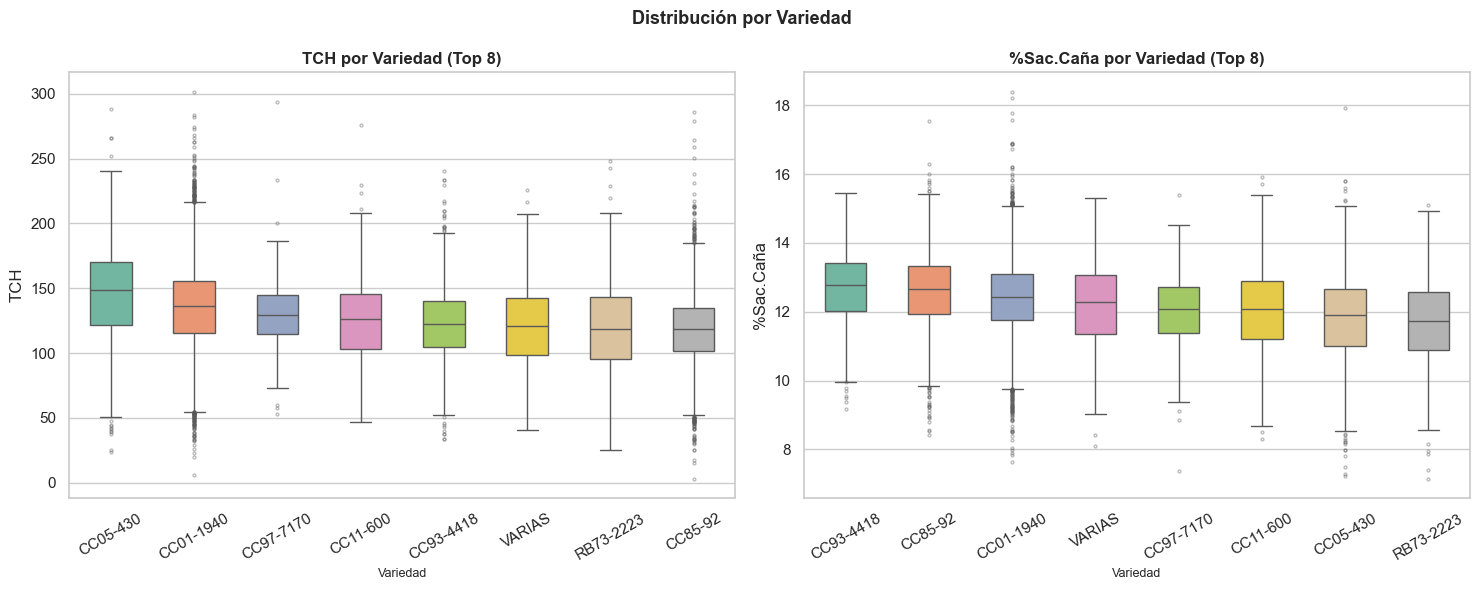

Figura guardada: outputs/figures/fig6_variedad_targets.png


In [17]:
# Top variedades
if "Variedad" in df_reg_clean.columns:
    top_vars = df_reg_clean["Variedad"].value_counts().head(8).index

    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    for ax, target in zip(axes, ["TCH", "%Sac.Caña"]):
        df_plot = df_reg_clean[df_reg_clean["Variedad"].isin(top_vars)][[target, "Variedad"]].dropna()
        order = df_plot.groupby("Variedad")[target].median().sort_values(ascending=False).index
        sns.boxplot(data=df_plot, x="Variedad", y=target, order=order, ax=ax,
                    palette="Set2", width=0.5,
                    flierprops={"marker": "o", "markersize": 2, "alpha": 0.4})
        ax.set_title(f"{target} por Variedad (Top 8)", fontweight='bold')
        ax.set_xlabel("Variedad", fontsize=9)
        ax.tick_params(axis='x', rotation=30)

    plt.suptitle("Distribución por Variedad", fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig("outputs/figures/fig6_variedad_targets.png", dpi=150, bbox_inches='tight')
    plt.show()
    print("Figura guardada: outputs/figures/fig6_variedad_targets.png")


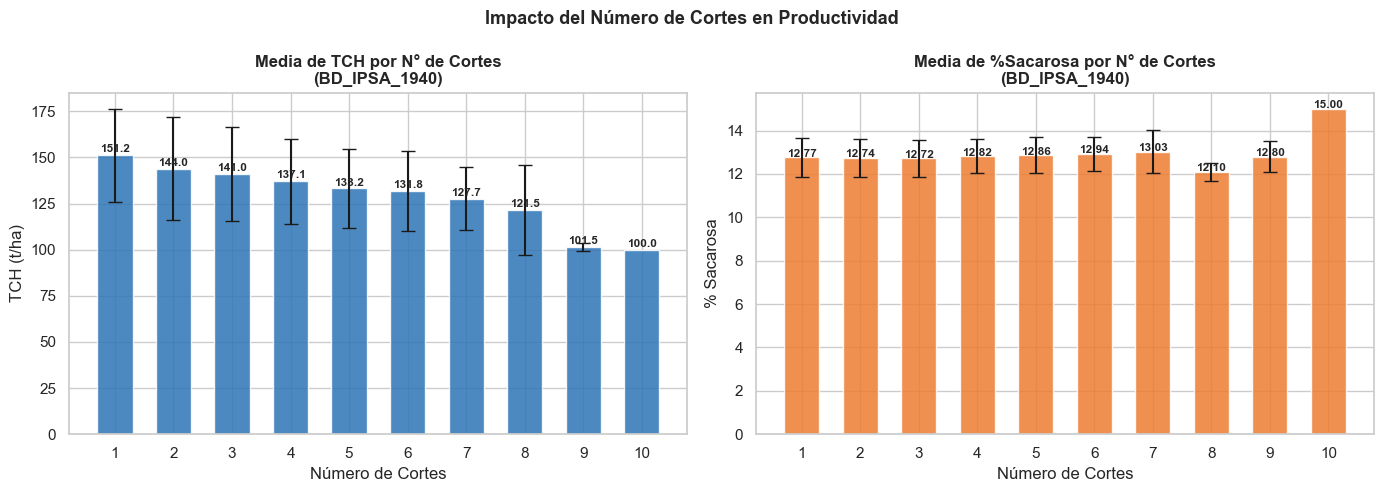

Figura guardada: outputs/figures/fig7_cortes_targets.png
Nota: se usó df_clf_clean con columnas 'cortes' y 'sacarosa'


In [18]:
# Análisis por número de cortes
# IMPORTANTE: En HISTORICO_SUERTES, "T.Corte" es el TIPO de corte (manual/mecánico),
# NO el número de cortes → convertirlo a numérico da NaN → gráfico vacío.
# BD_IPSA_1940 sí tiene la variable numérica "cortes" (número de cortes del ciclo).

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Detectar columna sacarosa en df_clf_clean ---
sac_col = next((c for c in df_clf_clean.columns if "sacarosa" in c.lower()), None)

# --- Panel izquierdo: cortes vs TCH ---
if "cortes" in df_clf_clean.columns and "TCH" in df_clf_clean.columns:
    df_c = df_clf_clean[["cortes", "TCH"]].dropna()
    df_c = df_c[df_c["cortes"].between(1, 10)]
    means_tch = df_c.groupby("cortes")["TCH"].mean()
    stds_tch  = df_c.groupby("cortes")["TCH"].std()
    axes[0].bar(means_tch.index, means_tch.values, color="#2E75B6", alpha=0.85,
                yerr=stds_tch.values, capsize=5, width=0.6, edgecolor="white")
    for x, y in zip(means_tch.index, means_tch.values):
        axes[0].text(x, y + 1.5, f"{y:.1f}", ha="center", fontsize=8.5, fontweight="bold")
    axes[0].set_title("Media de TCH por N° de Cortes\n(BD_IPSA_1940)", fontweight="bold")
    axes[0].set_xlabel("Número de Cortes")
    axes[0].set_ylabel("TCH (t/ha)")
    axes[0].set_xticks(means_tch.index)

# --- Panel derecho: cortes vs sacarosa ---
if "cortes" in df_clf_clean.columns and sac_col:
    df_c2 = df_clf_clean[["cortes", sac_col]].dropna()
    df_c2 = df_c2[df_c2["cortes"].between(1, 10)]
    means_sac = df_c2.groupby("cortes")[sac_col].mean()
    stds_sac  = df_c2.groupby("cortes")[sac_col].std()
    axes[1].bar(means_sac.index, means_sac.values, color="#ED7D31", alpha=0.85,
                yerr=stds_sac.values, capsize=5, width=0.6, edgecolor="white")
    for x, y in zip(means_sac.index, means_sac.values):
        axes[1].text(x, y + 0.02, f"{y:.2f}", ha="center", fontsize=8.5, fontweight="bold")
    axes[1].set_title(f"Media de %Sacarosa por N° de Cortes\n(BD_IPSA_1940)", fontweight="bold")
    axes[1].set_xlabel("Número de Cortes")
    axes[1].set_ylabel("% Sacarosa")
    axes[1].set_xticks(means_sac.index)

plt.suptitle("Impacto del Número de Cortes en Productividad", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("outputs/figures/fig7_cortes_targets.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figura guardada: outputs/figures/fig7_cortes_targets.png")
print(f"Nota: se usó df_clf_clean con columnas 'cortes' y '{sac_col}'")


## 4.6 EDA — BD_IPSA_1940 (Dataset de Clasificación)

Se exploran las distribuciones y relaciones en el dataset de clasificación.

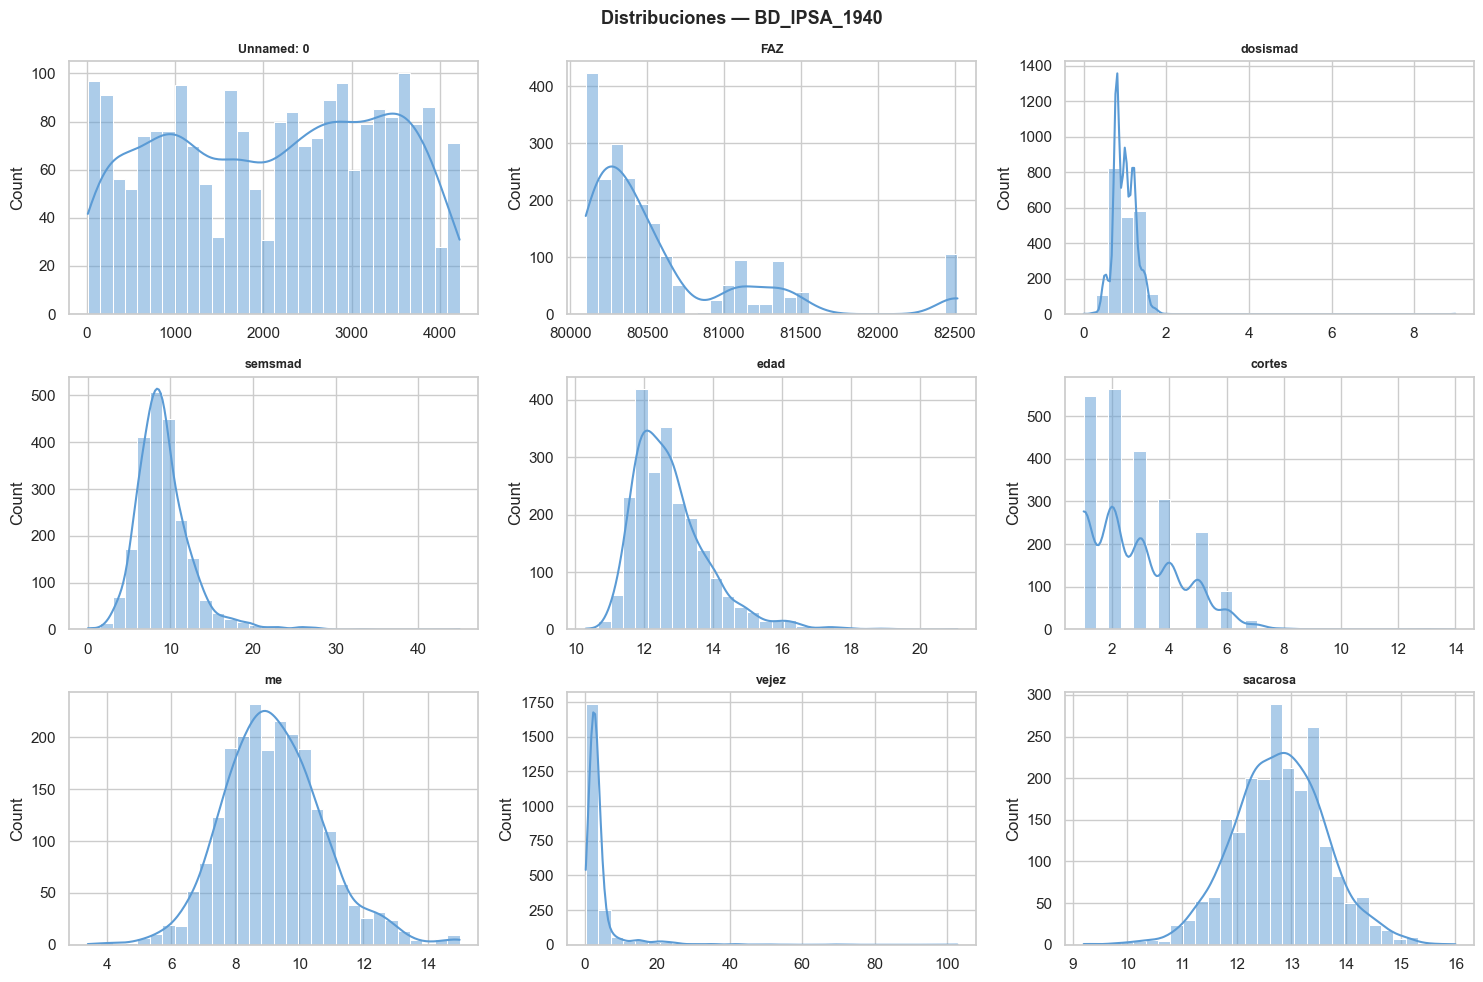

Figura guardada: outputs/figures/fig8_distribuciones_clf.png


In [19]:
# Distribuciones BD_IPSA_1940
num_cols_clf = df_clf_clean.select_dtypes(include='number').columns.tolist()
n_cols = min(len(num_cols_clf), 9)
selected = num_cols_clf[:n_cols]

fig, axes = plt.subplots(3, 3, figsize=(15, 10))
for ax, col in zip(axes.flat, selected):
    sns.histplot(df_clf_clean[col].dropna(), kde=True, ax=ax, color="#5B9BD5", bins=30)
    ax.set_title(col, fontweight='bold', fontsize=9)
    ax.set_xlabel("")
# Ocultar ejes vacíos
for ax in axes.flat[len(selected):]:
    ax.set_visible(False)

plt.suptitle("Distribuciones — BD_IPSA_1940", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("outputs/figures/fig8_distribuciones_clf.png", dpi=150, bbox_inches='tight')
plt.show()
print("Figura guardada: outputs/figures/fig8_distribuciones_clf.png")


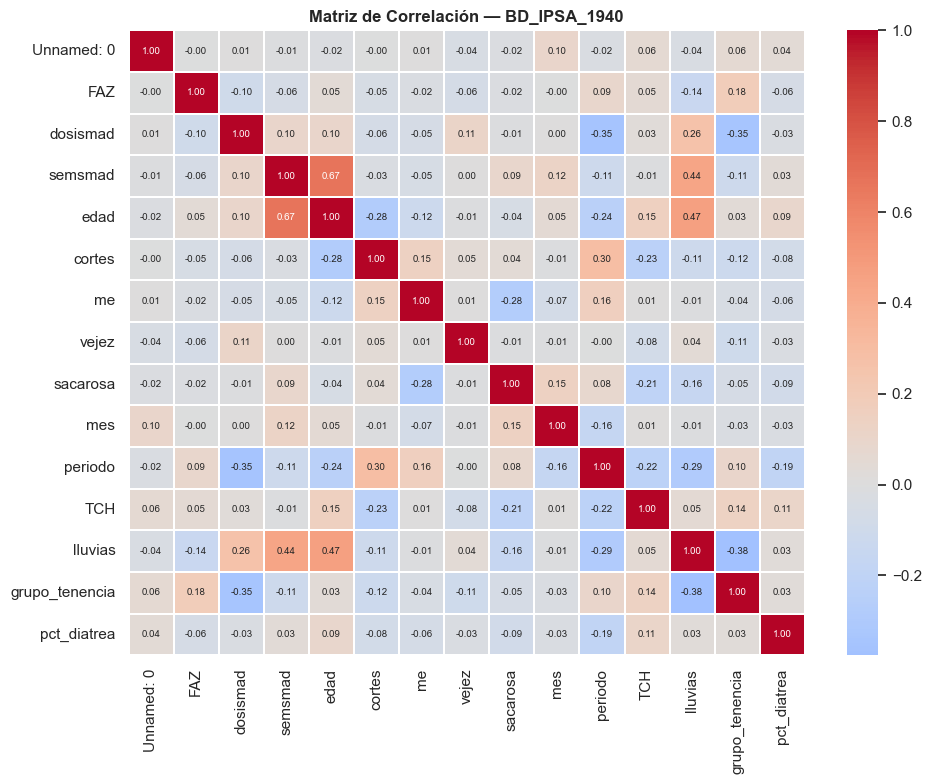

Figura guardada: outputs/figures/fig9_correlacion_clf.png

→ Correlación Edad-Cortes: -0.282 (negativa moderada — coherente con el ciclo de cultivo)


In [20]:
# Correlación BD_IPSA_1940
corr_clf = df_clf_clean.corr(numeric_only=True)
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_clf, cmap="coolwarm", center=0, annot=True, fmt=".2f",
            linewidths=0.3, ax=ax, annot_kws={"size": 7})
ax.set_title("Matriz de Correlación — BD_IPSA_1940", fontweight='bold', fontsize=12)
plt.tight_layout()
plt.savefig("outputs/figures/fig9_correlacion_clf.png", dpi=150, bbox_inches='tight')
plt.show()
print("Figura guardada: outputs/figures/fig9_correlacion_clf.png")

# Comentar correlación negativa Edad-Cortes
if "edad" in corr_clf.columns and "cortes" in corr_clf.columns:
    r = corr_clf.loc["edad","cortes"]
    print(f"\n→ Correlación Edad-Cortes: {r:.3f} (negativa moderada — coherente con el ciclo de cultivo)")


## 4.7 Factor de Inflación de la Varianza (VIF)

Se calcula el VIF para detectar multicolinealidad entre los predictores numéricos del dataset de regresión. VIF > 10 indica problemas severos; VIF > 5 es moderado.

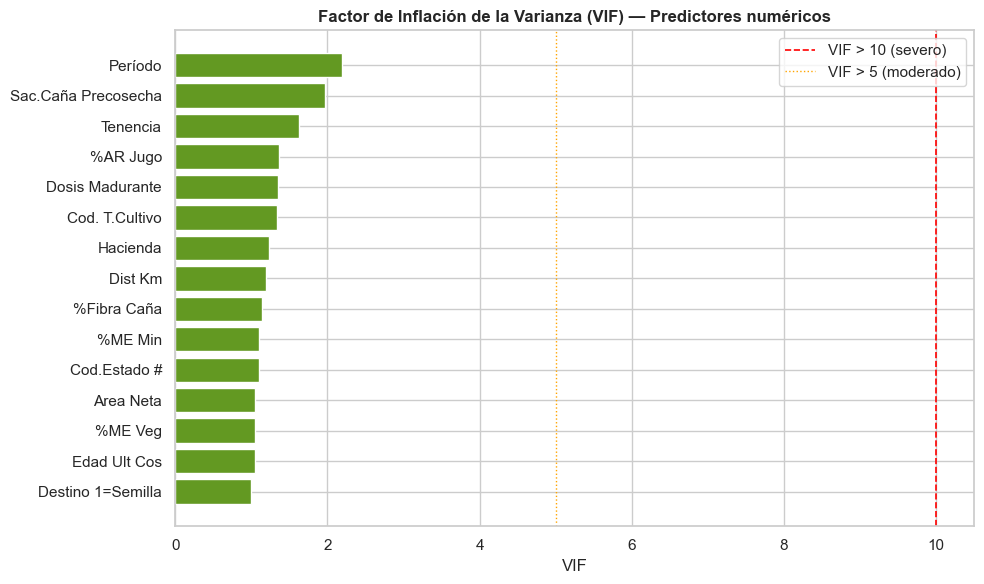

Figura guardada: outputs/figures/fig10_vif.png

Resumen VIF:
           Variable      VIF
            Período 2.189655
Sac.Caña Precosecha 1.964516
           Tenencia 1.624282
           %AR Jugo 1.358291
    Dosis Madurante 1.350125
     Cod. T.Cultivo 1.336481
           Hacienda 1.238093
            Dist Km 1.190886
        %Fibra Caña 1.139562
            %ME Min 1.098842
       Cod.Estado # 1.095248
          Area Neta 1.049367
            %ME Veg 1.048053
       Edad Ult Cos 1.046321
  Destino 1=Semilla 1.001100


In [21]:
# VIF manual sin statsmodels
from sklearn.linear_model import LinearRegression

def vif_manual(X_df):
    vif_vals = {}
    cols = list(X_df.columns)
    X_arr = X_df.values
    for i, col in enumerate(cols):
        y_vif = X_arr[:, i]
        X_rest = np.delete(X_arr, i, axis=1)
        lr = LinearRegression().fit(X_rest, y_vif)
        r2 = lr.score(X_rest, y_vif)
        vif_vals[col] = 1 / (1 - r2) if r2 < 1 else float('inf')
    return pd.DataFrame({"Variable": list(vif_vals.keys()), "VIF": list(vif_vals.values())})

# Solo numéricas, sin targets, sin NaN
X_vif = df_reg_clean.select_dtypes(include='number').drop(
    columns=["TCH", "%Sac.Caña"], errors='ignore').dropna()

# Limitar a máx 15 variables para eficiencia
X_vif = X_vif.iloc[:, :15] if X_vif.shape[1] > 15 else X_vif

vif_df = vif_manual(X_vif)
vif_df = vif_df.sort_values("VIF", ascending=False)

# Figura
fig, ax = plt.subplots(figsize=(10, 6))
colors_vif = ["#E24B4A" if v > 10 else "#EF9F27" if v > 5 else "#639922"
              for v in vif_df["VIF"]]
ax.barh(vif_df["Variable"][::-1], vif_df["VIF"][::-1], color=colors_vif[::-1])
ax.axvline(10, color='red', linestyle='--', linewidth=1.2, label='VIF > 10 (severo)')
ax.axvline(5,  color='orange', linestyle=':', linewidth=1.0, label='VIF > 5 (moderado)')
ax.set_xlabel("VIF")
ax.set_title("Factor de Inflación de la Varianza (VIF) — Predictores numéricos", fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig("outputs/figures/fig10_vif.png", dpi=150, bbox_inches='tight')
plt.show()
print("Figura guardada: outputs/figures/fig10_vif.png")
print("\nResumen VIF:")
print(vif_df.to_string(index=False))


## 4.8 Exportar Datos Limpios

Se exportan los datasets preprocesados para su uso en las tareas de modelado (Tarea 3).

In [22]:
df_reg_clean.to_csv("outputs/datos_limpios/HISTORICO_SUERTES_limpio.csv", index=False)
df_clf_clean.to_csv("outputs/datos_limpios/BD_IPSA_1940_limpio.csv", index=False)

print("Archivos exportados:")
print(f"  • outputs/datos_limpios/HISTORICO_SUERTES_limpio.csv  → {df_reg_clean.shape}")
print(f"  • outputs/datos_limpios/BD_IPSA_1940_limpio.csv       → {df_clf_clean.shape}")


Archivos exportados:
  • outputs/datos_limpios/HISTORICO_SUERTES_limpio.csv  → (20578, 43)
  • outputs/datos_limpios/BD_IPSA_1940_limpio.csv       → (2187, 21)


---
# 5. Modelamiento (Tarea 3)

> **Pendiente** — Esta sección incluirá:
> - 5.1 Creación de categorías para clasificación (TCH y %Sac.Caña en niveles alto/medio/bajo)
> - 5.2 División train/test (80/20) y validación cruzada k-fold (k=5)
> - 5.3 Modelos benchmark: Regresión Lineal Múltiple, Regresión Logística, KNN
> - 5.4 Modelos avanzados: Random Forest, XGBoost, SVM
> - 5.5 Ajuste de hiperparámetros (GridSearchCV)
> - 5.6 Importancia de características (feature importance)

---
# 6. Resultados y Conclusiones (Tarea 4)

> **Pendiente** — Esta sección incluirá:
> - 6.1 Tablas comparativas de desempeño (R², RMSE, MAE para regresión; Accuracy, F1, Kappa para clasificación)
> - 6.2 Matrices de confusión para clasificación
> - 6.3 Gráficos valores reales vs predichos para regresión
> - 6.4 Discusión de resultados en contexto agronómico
> - 6.5 Conclusiones y trabajo futuro